# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [263]:
import numpy as np

In [272]:
def spesa_mens(affitti):
    print(affitti.sum())

affitti = np.array([720.00, 980.00, 650.00, 1200.00])
spesa_mens(affitti)

affitti[affitti == 1200.00] *= 1.12
spesa_mens(affitti)

affitti[affitti == 650] *= 0.9
spesa_mens(affitti)

affitti[(affitti == 720) | (affitti == 980)] *= 1.05
spesa_mens(affitti)

affitti

3550.0
3694.0
3629.0
3714.0


array([ 756., 1029.,  585., 1344.])

In [33]:
canoni_mens = np.array([720.00, 980.00, 650.00, 1200.00])
spesa_tot_1 = canoni_mens.sum()
canoni_mens[canoni_mens == 1200] *= 1.12
# canoni_mens = np.where(canoni_mens == 1200, canoni_mens * 1.12, canoni_mens)
spesa_tot_2 = canoni_mens.sum()
canoni_mens[canoni_mens == 650] *= 0.9
canoni_mens[(canoni_mens == 720) | (canoni_mens == 980)] *= 1.05
print(f"canoni mensili: {canoni_mens}\nspesa totale: {canoni_mens.sum()}")
100 - (spesa_tot_1 * 100)/spesa_tot_2

canoni mensili: [ 756. 1029.  585. 1344.]
spesa totale: 3714.0


np.float64(3.8982133188955004)

## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

In [273]:
import random
import matplotlib.pyplot as plt


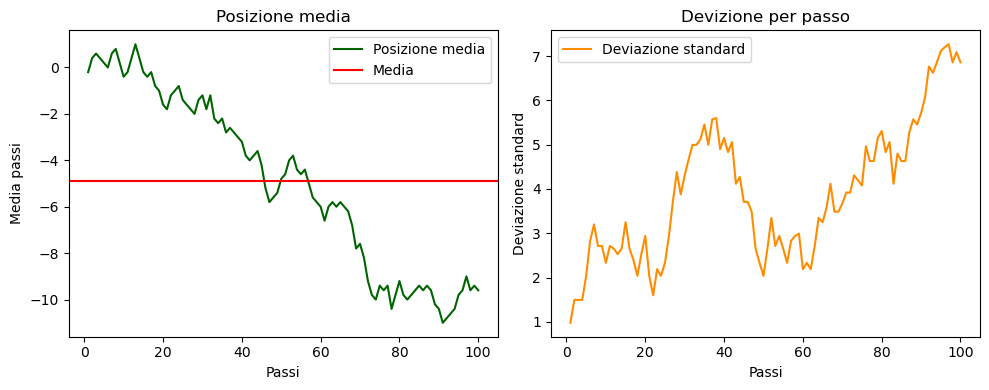

In [314]:
def cammino(passi, camminatori):
    cma = np.zeros(passi)       #lungo quanti sono i passi, ad ogni passo calcolo la media
    std_dev = np.zeros(passi)   #idem

    posizione = np.zeros(camminatori)   #non ha memoria
    #ad ogni passo
    for i in range(passi):
        #i camminatori fanno un passo
        for j, el in enumerate(posizione):
            passo = np.random.choice([-1, 1])
            posizione[j] += passo

        cma[i] = posizione.mean()
        std_dev[i] = np.std(posizione)
        #print(f"{posizione} {cma[i]} {std_dev[i]}\n")

    return cma, std_dev
    

passi = 100
camminatori = 5
cma, std_dev = cammino(passi, camminatori)

fig, sub = plt.subplots(1, 2, figsize=(10,4))

sub[0].plot(np.linspace(1, passi, passi), cma, color='darkgreen', label='Posizione media')
sub[0].set_title("Posizione media")
sub[0].set_xlabel("Passi")
sub[0].set_ylabel("Media passi")
sub[0].axhline(y=cma.mean(), color='red', label='Media')
sub[0].legend()

sub[1].plot(np.linspace(1, passi, passi), std_dev, color='darkorange', label='Deviazione standard')
sub[1].set_title("Devizione per passo")
sub[1].set_xlabel("Passi")
sub[1].set_ylabel("Deviazione standard")
sub[1].legend()

plt.tight_layout()

Text(0, 0.5, 'Media')

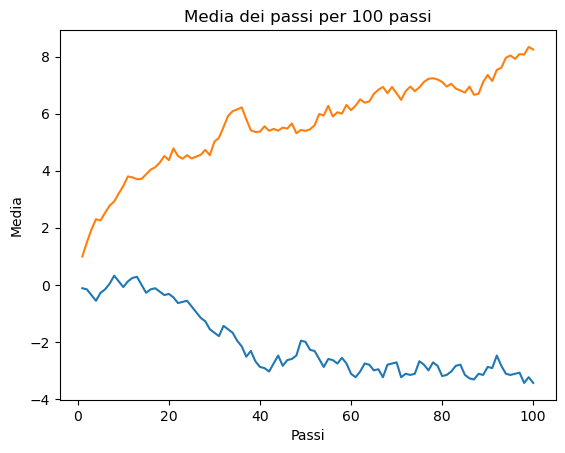

In [90]:
x = 0
def cammino(passi, camminatori):
    array_posizione = np.zeros(camminatori)
    cma = np.zeros(passi)
    std_dev = np.zeros(passi)

    #passi
    for i in range(passi):
        #aggiorno i passi per camminatore
        for j, el in enumerate(array_posizione):
            passo = random.choice([-1 ,1])
            array_posizione[j] += passo

        #cma
        cma[i] = array_posizione.sum()/camminatori
        std_dev[i] = np.std(array_posizione)

    return cma, std_dev

passi = 100
camminatori = 25
cma, std_dev = cammino(passi, camminatori)

x = np.linspace(1, passi, passi)
plt.plot(x, cma)
plt.plot(x, std_dev)
plt.title(f"Media dei passi per {passi} passi")
plt.xlabel("Passi")
plt.ylabel("Media")


La deviazione standard aumenta all'aumentare dei passi

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [315]:
import scipy.stats as st

In [326]:
rng = np.random.default_rng(seed=42)
a = rng.normal(loc=0, scale=1, size=(5,9))

val_min = abs(a - 0.1).argmin(axis=1)
val_min
i = 0
for el in a:
    print(el[val_min[i]])
    i += 1

a

0.12784040316728537
0.06603069756121605
-0.049925910986252896
0.36544406436407834
0.11668580914072822


array([[ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
        -1.30217951,  0.1278404 , -0.31624259, -0.01680116],
       [-0.85304393,  0.87939797,  0.77779194,  0.0660307 ,  1.12724121,
         0.46750934, -0.85929246,  0.36875078, -0.9588826 ],
       [ 0.8784503 , -0.04992591, -0.18486236, -0.68092954,  1.22254134,
        -0.15452948, -0.42832782, -0.35213355,  0.53230919],
       [ 0.36544406,  0.41273261,  0.430821  ,  2.1416476 , -0.40641502,
        -0.51224273, -0.81377273,  0.61597942,  1.12897229],
       [-0.11394746, -0.84015648, -0.82448122,  0.65059279,  0.74325417,
         0.54315427, -0.66550971,  0.23216132,  0.11668581]])

In [ ]:
#creo l'arra
rng = np.random.default_rng(seed=42) #restituise array di default
a = (rng.normal(loc=0.0, scale=1.0, size=(5,9)))

assoluti = np.abs(a - 0.1)
val_min = np.argmin(assoluti, axis=1) #trova il valore minimo (np.argmin) per ogni riga (axis = 1)

print(f"Indici valori minimi per ogni riga: {val_min}")


Indici valori minimi per ogni riga: [6 3 1 0 8]


In [119]:
# X = st.norm(loc=0, scale=1)
# x = np.linspace(-5, 5, 2000)
# plt.plot(x, X.pdf(x))

## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [138]:
import pandas as pd

Age
0.92     151.55000
64.00    144.50000
58.00     93.90166
35.00     89.31250
50.00     64.02583
           ...    
74.00      7.77500
70.50      7.75000
20.50      7.25000
23.50      7.22920
34.50      6.43750
Name: Fare, Length: 88, dtype: float64

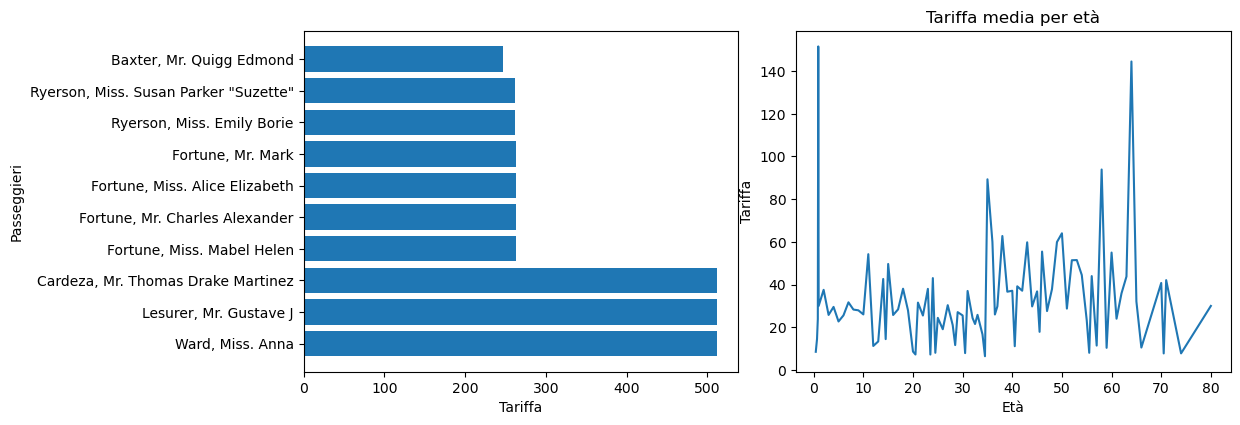

In [374]:
#importazione dataser
df = pd.read_csv('titanic.csv')

#10 passeggieri più paganti
df.sort_values(by='Fare', ascending=False).head(10)

#media age, fare, sibsp
medie = df[['Age', 'Fare', 'SibSp']].dropna().mean()    #la media non considera i nan di default

#Family index
df['Family_index'] = (df['SibSp'] + df['Parch']) / df['Fare']   #se Fare = 0 o missing, Family_index = missing
df.sort_values(by='Fare')

#Max Faminly_index
df[df['Family_index'] == df['Family_index'].max()]

#(filtro il nome) Fare > 100
df[df['Fare'] > 100][['Name', 'Fare']].sort_values(by='Fare')

#Formatazione grafici
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plt.tight_layout()

#grafico
assi = df.sort_values(by='Fare', ascending=False).head(10)
x = assi['Fare']
y = assi['Name']
ax[0].barh(y, x)
ax[0].set_xlabel('Tariffa')
ax[0].set_ylabel('Passeggieri')

#grafico a linee età ordinato per fare
#ordino
nuovo_df = df.sort_values(by='Fare').dropna()
medie_per_eta = df.groupby('Age')['Fare'].mean()
y_media_fare = medie_per_eta.values
x_eta = medie_per_eta.index
ax[1].plot(x_eta, y_media_fare)
ax[1].set_xlabel('Età')
ax[1].set_ylabel('Tariffa')
ax[1].set_title('Tariffa media per età')

medie_per_eta.sort_values(ascending=False)

35.67 78.68 0.46


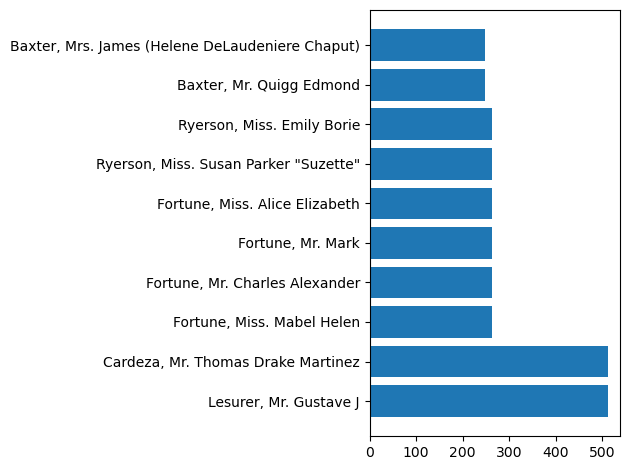

In [165]:
df = pd.read_csv("titanic.csv")

df.dropna(inplace=True)

ricchi = df.sort_values(by='Fare',ascending=False).head(10)

eta_media = round(df["Age"].mean(), 2)
tariffa_media = round(df["Fare"].mean(), 2)
parenti_a_bordo_medi = round(df["SibSp"].mean(), 2)
print(eta_media, tariffa_media, parenti_a_bordo_medi)

df["Family_index"] = round((df["SibSp"] + df["Parch"]) / df["Fare"], 3)
df[df["Family_index"] == df["Family_index"].max()]

df[df["Fare"] > 100]

plt.barh(ricchi.Name, ricchi.Fare)
plt.tight_layout()


In [ ]:
df.sort_values(by='Fare',ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,0.000
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,0.002
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,0.019
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,0.019
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,0.019
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,0.019
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,0.015
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,0.015
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,0.004
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C,0.004


In [ ]:
#Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.
#ordino il df per tariffa
nuovo_df = df.sort_values(by='Fare', ascending=False)

nuovo_df
x = nuovo_df["Age"]
y = nuovo_df["Fare"]

prov = df.groupby("Fare")["Age"].count()
fare = prov.index
age = prov.values

plt.plot(fare, age)


KeyError: 'Fare'

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [200]:
import seaborn as sns

In [249]:
df = sns.load_dataset("penguins")

In [203]:
df.shape

(344, 7)

In [242]:
na_per_col = len(df) - df.count() #righe totali - righe non nulle
na_per_col
#meglio
print(df.isna().sum())



species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [253]:
df["sex"].value_counts()

df["sex"] = df["sex"].fillna("Male", inplace=True)
df.dropna(subset=["body_mass_g"], inplace=True)
df.isna().sum()

df.duplicated()

/var/folders/kd/98j8qsb161z9gz322n9jk3vh0000gn/T/ipykernel_19197/2650462558.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["sex"] = df["sex"].fillna("Male", inplace=True)


0      False
1      False
2      False
4      False
5      False
       ...  
338    False
340    False
341    False
342    False
343    False
Length: 342, dtype: bool

<Axes: xlabel='body_mass_g', ylabel='species'>

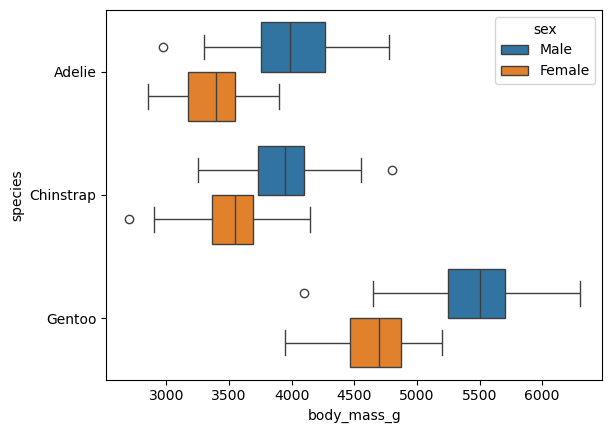

In [261]:
#massa corporea media per specie
media_specie = round(df.groupby("species")["body_mass_g"].mean(), 2)

#non serve ma se serve... WIP
# df["body_mass_g"] = df["body_mass_g"].fillna(media_specie)
# df.isna().sum()

sns.boxplot(data=df, x="body_mass_g", y="species", hue="sex")

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


In [262]:
x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, 100)